<a href="https://colab.research.google.com/github/Guilher-cell/CP1_SERS-Analise_Database_Energia_API-/blob/main/CP01_Desafio2_sers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Desenvolva aqui o DESAFIO 1

dados = pd.DataFrame(registros)


In [ ]:
dados.head()


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
dados.shape


(336, 11)

In [ ]:
dados.columns


Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [ ]:
dados.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


Os atributos  que representam data/hora: data de referencia , área de carga: cod_areacarga e valor de carga: valor_carga_global.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# Desenvolva aqui o DESAFIO 2
dados = dados.rename(columns={'val_cargaglobal': 'valor_carga_global',
                           'val_cargaglobalsmmgd':'valor_carga_global_smmgd',
                           'val_cargasupervisionada':'valor_carga_supervisionada',
                           'val_carganaosupervisionada':'valor_carga_nao_supervisionado',
                           'val_cargammgd':'valor_carga_mmgd',
                           'val_consistencia':'valor_consistencia'})


In [ ]:
df = dados['valor_carga_global']
df.head()

,valor_carga_global
0,15913.618
1,15251.414
2,14606.733
3,14182.290
4,13838.488


In [ ]:
dados.isnull().sum()

,0
cod_areacarga,0
din_atualizacao,0
dat_referencia,0
din_referenciautc,0
valor_carga_global,0
val_cargaglobalcons,0
valor_carga_global_smmgd,0
valor_carga_supervisionada,0
valor_carga_nao_supervisionado,0
valor_carga_mmgd,0


In [ ]:
dados['valor_carga_global']

,valor_carga_global
0,15913.618
1,15251.414
2,14606.733
3,14182.290
4,13838.488
...,...
331,20930.443
332,19936.190
333,19153.877
334,18149.570


In [ ]:
print(dados['dat_referencia'].dtype)
print(dados['din_referenciautc'].dtype)

object
object


In [ ]:
dados['dat_referencia'] = pd.to_datetime(dados['dat_referencia'])
dados['din_referenciautc'] = pd.to_datetime(dados['din_referenciautc'])

As colunas `dat_referencia` e `din_referenciautc` foram convertidas para o formato de data/hora utilizando `pd.to_datetime()`. Essa conversão facilita a realização de análises temporais e permite utilizar corretamente os valores de data e hora nos gráficos e demais análises.

A coluna `din_referenciautc` representa a data e hora da medição em UTC e foi mantida nesse padrão para preservar o horário original dos dados.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desenvolva aqui o DESAFIO 3
minima = dados['valor_carga_global'].min()


In [ ]:
maxima = dados['valor_carga_global'].max()


In [ ]:
dados['valor_carga_global'].mean()

np.float64(17870.828980654762)

In [ ]:
dados['valor_carga_global'].median()

18199.1285

In [ ]:
amplitude = maxima - minima
print('A amplitude é: ',amplitude)

A amplitude é:  11046.059000000001


In [ ]:
total = dados.size
print('O total de medições é: ',total)

O total de medições é:  3696


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4
Maior_consumo= dados['valor_carga_global'].max()
P90 = 0.90 * Maior_consumo
df1 = dados[dados['valor_carga_global']> P90]
df1.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,valor_carga_global,val_cargaglobalcons,valor_carga_global_smmgd,valor_carga_supervisionada,valor_carga_nao_supervisionado,valor_carga_mmgd,valor_consistencia
35,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 21:00:00+00:00,21088.959,21088.959,20955.120,19516.370,1438.7495,133.8406,0
36,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 21:30:00+00:00,22398.360,22398.360,22377.096,20933.746,1443.3496,21.2638,0
37,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 22:00:00+00:00,23185.312,23185.312,23164.182,21717.934,1446.2487,21.1300,0
38,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 22:30:00+00:00,22903.314,22903.314,22882.184,21433.580,1448.6025,21.1300,0
39,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 23:00:00+00:00,22358.701,22358.701,22337.570,20886.078,1451.4915,21.1300,0


In [ ]:
quantidade = len(df1)
print(f'Os registros são: {quantidade}')

Os registros são: 50


In [ ]:
percentual = quantidade / len(dados) * 100
print(f'Percentual: {percentual:.2f}%')

Percentual: 14.88%


In [ ]:
maior_carga = df1['valor_carga_global'].max()
print(f'O maior valor de carga é: {maior_carga:.3f} MW')

O maior valor de carga é: 23185.312 MW


In [ ]:
indice_pico = dados['valor_carga_global'].idxmax()

pico = dados.loc[indice_pico]

print(f'Carga máxima: {pico["valor_carga_global"]:.3f} MW')
print(f'Data: {pico["dat_referencia"]}')
print(f'Horário: {pico["din_referenciautc"]}')

Carga máxima: 23185.312 MW
Data: 2025-08-01 00:00:00
Horário: 2025-08-01 22:00:00+00:00


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Desenvolva aqui o DESAFIO 5
# Carga acima da média
df2 = dados[dados['valor_carga_global'] > dados['valor_carga_global'].mean()]
df2.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,valor_carga_global,val_cargaglobalcons,valor_carga_global_smmgd,valor_carga_supervisionada,valor_carga_nao_supervisionado,valor_carga_mmgd,valor_consistencia
15,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,18096.023,17415.600,15954.084,1461.5154,680.4232,0
16,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,18629.395,17409.600,15953.951,1455.6488,1219.7958,0
17,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,18825.176,17097.592,15648.688,1448.9040,1727.5842,0
18,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,19056.504,16850.477,15407.757,1442.7206,2206.0276,0
19,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,19427.822,16792.590,15353.431,1439.1598,2635.2324,0


In [ ]:
# Carga abaixo de uma porcentagem maxima
df3 = dados[dados['valor_carga_global'] < 0.9 * dados['valor_carga_global'].max()]
df3.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,valor_carga_global,val_cargaglobalcons,valor_carga_global_smmgd,valor_carga_supervisionada,valor_carga_nao_supervisionado,valor_carga_mmgd,valor_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 03:30:00+00:00,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 04:00:00+00:00,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 04:30:00+00:00,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 05:00:00+00:00,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 05:30:00+00:00,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
# Intervalo de valores
df4 = dados[(dados['valor_carga_global'] >= 100000) & (dados['valor_carga_global'] <= 200000)]
df4.head()


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,valor_carga_global,val_cargaglobalcons,valor_carga_global_smmgd,valor_carga_supervisionada,valor_carga_nao_supervisionado,valor_carga_mmgd,valor_consistencia


In [ ]:
# Determinado dia ou período
df5 = dados[(dados['dat_referencia'] >= '2025-08-01') & (dados['dat_referencia'] <= '2025-08-07')]
df5.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,valor_carga_global,val_cargaglobalcons,valor_carga_global_smmgd,valor_carga_supervisionada,valor_carga_nao_supervisionado,valor_carga_mmgd,valor_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 03:30:00+00:00,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 04:00:00+00:00,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 04:30:00+00:00,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 05:00:00+00:00,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 05:30:00+00:00,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
# Combinação de duas condições
df6 = dados[(dados['valor_carga_global'] > 100000) & (dados['dat_referencia'] >= '2025-08-01')]
df6.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,valor_carga_global,val_cargaglobalcons,valor_carga_global_smmgd,valor_carga_supervisionada,valor_carga_nao_supervisionado,valor_carga_mmgd,valor_consistencia


In [ ]:
# Critério Escolhido para o Desafio 5: Carga acima da média
print("Novo DataFrame (Carga acima da média):")
display(df2.head())

quantidade_df2 = len(df2)
print(f'Quantidade de registros no df2: {quantidade_df2}')

percentual_df2 = (quantidade_df2 / len(dados)) * 100
print(f'Percentual de registros do df2 em relação ao total: {percentual_df2:.2f}%')

Novo DataFrame (Carga acima da média):


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,valor_carga_global,val_cargaglobalcons,valor_carga_global_smmgd,valor_carga_supervisionada,valor_carga_nao_supervisionado,valor_carga_mmgd,valor_consistencia
15,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,18096.023,17415.600,15954.084,1461.5154,680.4232,0
16,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,18629.395,17409.600,15953.951,1455.6488,1219.7958,0
17,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,18825.176,17097.592,15648.688,1448.9040,1727.5842,0
18,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,19056.504,16850.477,15407.757,1442.7206,2206.0276,0
19,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,19427.822,16792.590,15353.431,1439.1598,2635.2324,0


Quantidade de registros no df2: 184
Percentual de registros do df2 em relação ao total: 54.76%


In [ ]:
print("\nComparação com o conjunto de alta demanda (df1):")
# Aqui, vamos comparar baseando-nos nos índices, assumindo que são os mesmos registros.

registros_comuns_df1_df2 = pd.merge(df1, df2, how='inner', on=list(df1.columns))

quantidade_comum = len(registros_comuns_df1_df2)
percentual_comum_df1 = (quantidade_comum / len(df1)) * 100
percentual_comum_df2 = (quantidade_comum / len(df2)) * 100

print(f'Registros em alta demanda (df1): {len(df1)}')
print(f'Registros acima da média (df2): {len(df2)}')
print(f'Registros que estão em AMBOS (df1 e df2): {quantidade_comum}')
print(f'Percentual de registros de alta demanda que também estão acima da média: {percentual_comum_df1:.2f}%')
print(f'Percentual de registros acima da média que também estão em alta demanda: {percentual_comum_df2:.2f}%')


Comparação com o conjunto de alta demanda (df1):
Registros em alta demanda (df1): 50
Registros acima da média (df2): 184
Registros que estão em AMBOS (df1 e df2): 50
Percentual de registros de alta demanda que também estão acima da média: 100.00%
Percentual de registros acima da média que também estão em alta demanda: 27.17%


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

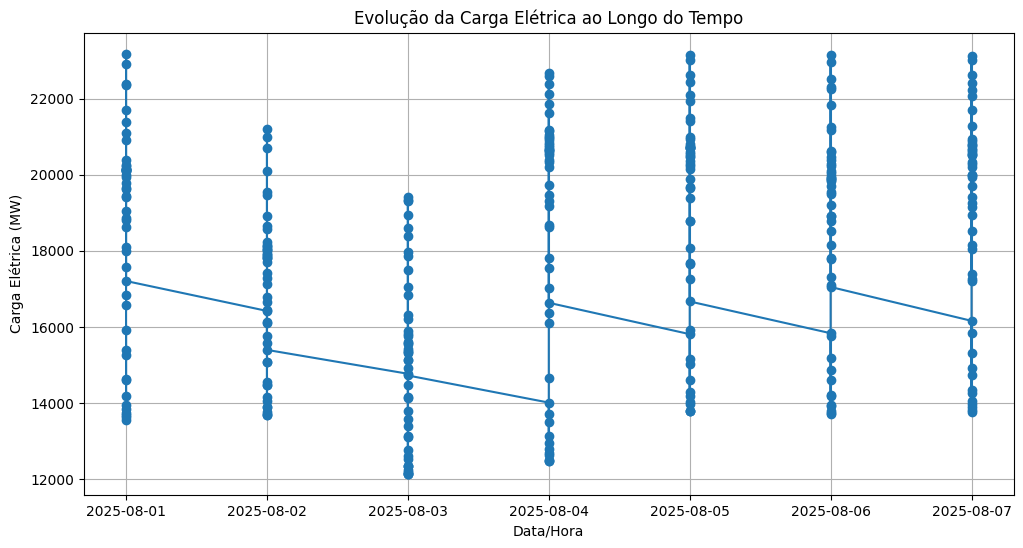

Este gráfico mostra a evolução da carga elétrica em São Paulo (SP) ao longo dos dias de 1 a 7 de agosto de 2025.
Podemos observar um padrão diário com picos de carga durante certas horas do dia e quedas em outras, refletindo o consumo típico.
Há também uma variação na carga máxima e mínima entre os dias, mas o padrão geral de elevação e queda ao longo do dia é consistente.


In [ ]:
# Desenvolva aqui o DESAFIO 6
# Representa o comportamento da carga ao longo das observações ou do tempo.
plt.figure(figsize=(12, 6))
plt.plot(dados['dat_referencia'], dados['valor_carga_global'], marker='o', linestyle='-')
plt.title('Evolução da Carga Elétrica ao Longo do Tempo')
plt.xlabel('Data/Hora')
plt.ylabel('Carga Elétrica (MW)')
plt.grid(True)
plt.show()

print("Este gráfico mostra a evolução da carga elétrica em São Paulo (SP) ao longo dos dias de 1 a 7 de agosto de 2025.\nPodemos observar um padrão diário com picos de carga durante certas horas do dia e quedas em outras, refletindo o consumo típico.\nHá também uma variação na carga máxima e mínima entre os dias, mas o padrão geral de elevação e queda ao longo do dia é consistente.")


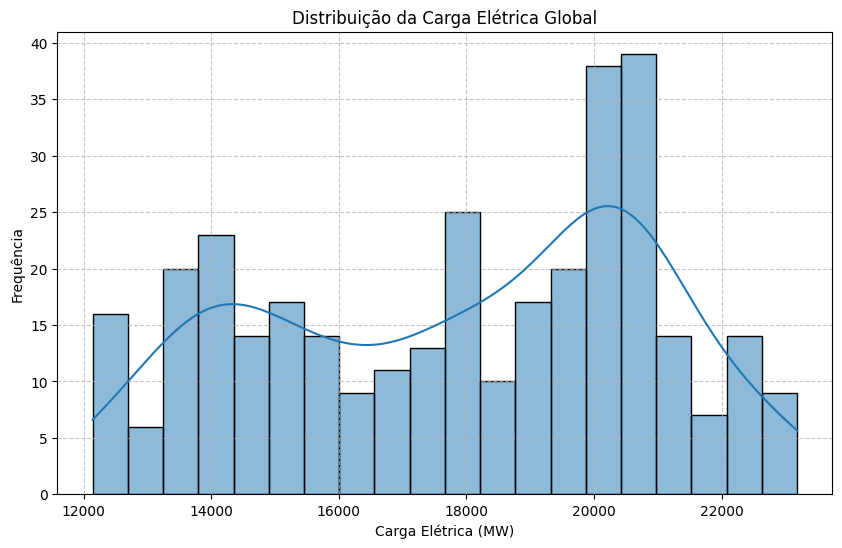

Este histograma exibe a distribuição da carga elétrica global.
Observa-se que a maioria dos valores de carga se concentra em uma faixa específica, indicando que a carga elétrica tende a operar dentro de um determinado intervalo na maior parte do tempo.
Há uma cauda, sugerindo que valores de carga mais altos são menos frequentes, mas ocorrem.


In [ ]:
# Segundo gráfico: Distribuição da Carga Elétrica Global (Histograma)
plt.figure(figsize=(10, 6))
sns.histplot(dados['valor_carga_global'], kde=True, bins=20)
plt.title('Distribuição da Carga Elétrica Global')
plt.xlabel('Carga Elétrica (MW)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Este histograma exibe a distribuição da carga elétrica global.\nObserva-se que a maioria dos valores de carga se concentra em uma faixa específica, indicando que a carga elétrica tende a operar dentro de um determinado intervalo na maior parte do tempo.\nHá uma cauda, sugerindo que valores de carga mais altos são menos frequentes, mas ocorrem.")

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

In [ ]:
regiao_analisada = parametros['cod_areacarga']
periodo_analisado = f"{parametros['dat_inicio']} a {parametros['dat_fim']}"
quantidade_registros_total = len(dados)

carga_minima = dados['valor_carga_global'].min()
carga_maxima = dados['valor_carga_global'].max()
carga_media = dados['valor_carga_global'].mean()
mediana_carga = dados['valor_carga_global'].median()

limiar_alta_demanda = 0.90 * carga_maxima
quantidade_alta_demanda = len(df1)
percentual_alta_demanda = (quantidade_alta_demanda / quantidade_registros_total) * 100

pico_registro = dados.loc[dados['valor_carga_global'].idxmax()]
momento_do_pico = f"{pico_registro['dat_referencia'].strftime('%Y-%m-%d')} às {pico_registro['din_referenciautc'].strftime('%H:%M')} (UTC)"

segundo_criterio_descricao = "Carga acima da média"
quantidade_segundo_criterio = len(df2)
percentual_segundo_criterio = (quantidade_segundo_criterio / quantidade_registros_total) * 100

In [ ]:
resumo_resultados = f'''
# Relatório Preliminar de Análise de Carga Elétrica

## Caracterização do Conjunto de Dados
- **Região analisada:** {regiao_analisada}
- **Período analisado:** {periodo_analisado}
- **Quantidade total de registros:** {quantidade_registros_total} observações

## Indicadores Estatísticos da Carga Elétrica
- **Carga mínima:** {carga_minima:.3f} MW
- **Carga máxima:** {carga_maxima:.3f} MW
- **Carga média:** {carga_media:.3f} MW
- **Mediana da carga:** {mediana_carga:.3f} MW

## Análise de Alta Demanda (Critério 1: 90% da Carga Máxima)
- **Limiar de alta demanda:** {limiar_alta_demanda:.3f} MW
- **Registros de alta demanda (df1):** {quantidade_alta_demanda} registros
- **Percentual de alta demanda:** {percentual_alta_demanda:.2f}%
- **Momento do pico de carga:** {momento_do_pico}

## Análise do Segundo Critério (Critério 2: {segundo_criterio_descricao})
- **Quantidade de registros no df2:** {quantidade_segundo_criterio} registros
- **Percentual do segundo critério:** {percentual_segundo_criterio:.2f}%

## Comparação entre os Critérios
- **Registros comuns a df1 (alta demanda) e df2 (acima da média):** {len(registros_comuns_df1_df2)} registros
- **Percentual de registros de alta demanda que também estão acima da média (em relação a df1):** {percentual_comum_df1:.2f}%
- **Percentual de registros acima da média que também estão em alta demanda (em relação a df2):** {percentual_comum_df2:.2f}%
'''

print(resumo_resultados)


# Relatório Preliminar de Análise de Carga Elétrica

## Caracterização do Conjunto de Dados
- **Região analisada:** SP
- **Período analisado:** 2025-08-01 a 2025-08-07
- **Quantidade total de registros:** 336 observações

## Indicadores Estatísticos da Carga Elétrica
- **Carga mínima:** 12139.253 MW
- **Carga máxima:** 23185.312 MW
- **Carga média:** 17870.829 MW
- **Mediana da carga:** 18199.128 MW

## Análise de Alta Demanda (Critério 1: 90% da Carga Máxima)
- **Limiar de alta demanda:** 20866.781 MW
- **Registros de alta demanda (df1):** 50 registros
- **Percentual de alta demanda:** 14.88%
- **Momento do pico de carga:** 2025-08-01 às 22:00 (UTC)

## Análise do Segundo Critério (Critério 2: Carga acima da média)
- **Quantidade de registros no df2:** 184 registros
- **Percentual do segundo critério:** 54.76%

## Comparação entre os Critérios
- **Registros comuns a df1 (alta demanda) e df2 (acima da média):** 50 registros
- **Percentual de registros de alta demanda que também estão 

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 16.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:

prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA**

---

### 1. Caracterização do Conjunto Analisado
* **Região de Análise:** SP (São Paulo)
* **Período de Coleta:** 01/08/2025 a 07/08/2025
* **Volume de Dados:** 336 observações (registros temporais)

---

### 2. Principais Indicadores
Com base no total de 336 observações da carga elétrica da região SP, destacam-se os seguintes indicadores estatísticos observados:

* **Carga Mínima:** 12.139,253 MW
* **Carga Máxima:** 23.185,312 MW
* **Carga Média:** 17.870,829 MW
* **Mediana da Carga:** 18.199,128 MW

---

### 3. Análise dos Períodos de Alta Demanda
A alta demanda foi delimitada pelo **Critério 1**, correspondente aos registros que atingiram ou ultrapassaram **90% da carga máxima** observada.

* **Limiar Calculado:** 20.866,781 MW
* **Registros Observados (df1):** 50 registros
* **Proporção do Período:** 14,88% do total de observações
* **Pico Máximo Registrado:** Ocorreu no dia **01/08/2025 às 22:00 (UTC)**, atingindo o valor absolut

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

------------------------------------------------------------------------

### Respostas do Desafio 9 — Validação Crítica

1. **Os indicadores foram utilizados corretamente?**

    Sim. O relatório utilizou exatamente os valores de carga mínima (12.139,253 MW), máxima (23.185,312 MW), média (17.870,829 MW) e mediana (18.199,128 MW) calculados no Desafio 3.

2. **Há alguma afirmação que não pode ser confirmada pelos dados?**

   Não. O relatório se restringiu aos dados fornecidos no resumo de resultados, sem extrapolações.

3. **Houve interpretação exagerada ou causalidade não demonstrada?**

   Não. A IA explicitamente diferenciou resultados observados de hipóteses, conforme solicitado no prompt, evitando atribuir o pico a causas externas sem evidências.

4. **Que alterações a equipe realizou no texto?**

   Foram realizados pequenos ajustes de formatação e a confirmação de que os horários citados estão em padrão UTC, mantendo a integridade técnica dos dados da API.

------------------------------------------------------------------------

## Relatório Final Revisado

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA — ESTADO DE SÃO PAULO**

**1. Caracterização do Conjunto Analisado**
Análise da carga elétrica na região de São Paulo (SP) entre 01/08/2025 e 07/08/2025, baseada em 336 registros oficiais obtidos via API do ONS.

**2. Principais Indicadores**
*   **Carga Mínima:** 12.139,253 MW
*   **Carga Máxima:** 23.185,312 MW
*   **Carga Média:** 17.870,829 MW
*   **Mediana:** 18.199,128 MW
A carga apresentou uma amplitude de 11.046,059 MW, operando acima da média em 54,76% do tempo analisado.

**3. Alta Demanda e Pico**
Utilizando o limiar de 90% da carga máxima (20.866,781 MW), identificou-se que períodos de alta demanda representam 14,88% do período. O pico absoluto de consumo ocorreu em **01/08/2025 às 22:00 (UTC)**.

**4. Comparação de Critérios**
A análise confirmou que 100% dos registros de alta demanda (Critério 1) estão contidos no conjunto de registros acima da média (Critério 2). O Critério 2 oferece uma visão mais ampla da ocupação do sistema, cobrindo mais da metade das observações.

**5. Conclusão**
O sistema elétrico em SP manteve um padrão de consumo onde a alta demanda extrema é pontual (~15% do tempo). O pico identificado no início do período monitorado é um fato observado, enquanto as causas para tais variações permanecem como hipóteses a serem validadas com dados climáticos ou operacionais adicionais.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**